In [1]:
# MDP Development
states = list(range(101))
gambler_mdp = dict.fromkeys(states)
ph = 0.4
pt = 1 - ph
gamma = 1

for s in states:
    if s in (0, 100):
        gambler_mdp[s] = {}
        continue

    max_stake = min(s, 100 - s)
    action_space = list(range(max_stake + 1))

    action_dict = {}

    for stake in action_space:
        win_state = s + stake
        lose_state = s - stake

        reward_win = 1 if win_state == 100 else 0
        reward_lose = 1 if lose_state == 100 else 0

        action_dict[stake] = [
            (ph, win_state, reward_win),
            (pt, lose_state, reward_lose)
        ]

    gambler_mdp[s] = action_dict


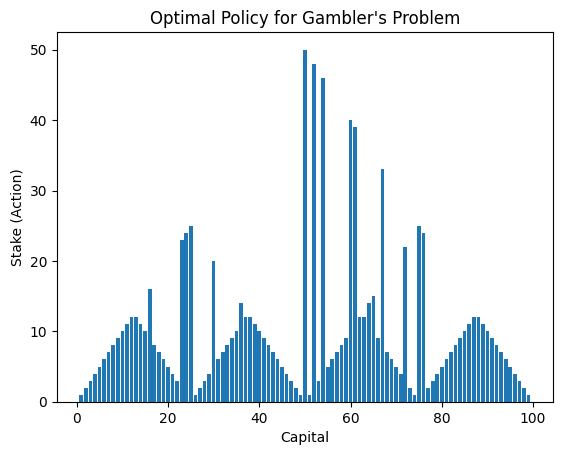

In [13]:
# Value Iteration and Bar Graph
import matplotlib.pyplot as plt

V = [1.0 for _ in range(101)]
V_new = [0.0 for _ in range(101)]

V[100] = 1
V_new[100] = 1

policy_old = [0 for _ in range(100)]
policy_new = [1 for _ in range(100)]

eps = 1e-3
gamma = 1

valid_states = list(range(1, 100))
iteration = 0

while True:
    iteration += 1

    policy_old = policy_new.copy()
    V = V_new.copy()

    for s in valid_states:
        best_val = 0
        best_act = 0

        for a in range(1, min(s, 100 - s) + 1):
            t_win = gambler_mdp[s][a][0]
            t_lose = gambler_mdp[s][a][1]

            val = (
                t_win[0] * (t_win[2] + gamma * V[t_win[1]]) +
                t_lose[0] * (t_lose[2] + gamma * V[t_lose[1]])
            )

            if val > best_val:
                best_val = val
                best_act = a

        V_new[s] = best_val

    delta = max(abs(V_new[s] - V[s]) for s in valid_states)

    if delta < eps:
        for s in valid_states:
            best_val = 0
            best_act = 0

            for a in range(1, min(s, 100 - s) + 1):
                t_win = gambler_mdp[s][a][0]
                t_lose = gambler_mdp[s][a][1]

                val = (
                    t_win[0] * (t_win[2] + gamma * V_new[t_win[1]]) +
                    t_lose[0] * (t_lose[2] + gamma * V_new[t_lose[1]])
                )

                if val > best_val:
                    best_val = val
                    best_act = a

            policy_new[s] = best_act
        break

policy = policy_new.copy()

plt.figure()
plt.bar(range(1, 100), [policy[s] for s in range(1, 100)])
plt.xlabel("Capital")
plt.ylabel("Stake (Action)")
plt.title("Optimal Policy for Gambler's Problem")
plt.show()


